# PS0: Setup & Dataset Download

In [ ]:
import torch
torch.cuda.is_available()


True

In [ ]:
!pip install -q kaggle


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d alxmamaev/flowers-recognition


Dataset URL: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition
License(s): unknown
 67% 151M/225M [00:00<00:00, 1.57GB/s]
100% 225M/225M [00:00<00:00, 961MB/s] 


In [ ]:
!unzip -q flowers-recognition.zip


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import numpy as np
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [ ]:
train_tf = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_tf = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])


In [ ]:
dataset = datasets.ImageFolder("flowers", transform=train_tf)
class_names = dataset.classes
num_classes = len(class_names)

target = {0:100, 1:500, 2:200, 3:50, 4:150}
indices, counter = [], Counter()

for i, (_, y) in enumerate(dataset):
    if counter[y] < target[y]:
        indices.append(i)
        counter[y] += 1

imbalanced_ds = Subset(dataset, indices)
counter


Counter({0: 100, 1: 500, 2: 200, 3: 50, 4: 150})

In [ ]:
train_size = int(0.8 * len(imbalanced_ds))
val_size = len(imbalanced_ds) - train_size

train_ds, val_ds = torch.utils.data.random_split(
    imbalanced_ds, [train_size, val_size]
)

val_ds.dataset.dataset.transform = test_tf

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)


# PS1 — CUSTOM CNN

In [ ]:
class FlowerCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(128*16*16, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

cnn = FlowerCNN().to(device)


# PS2 — IMBALANCE HANDLING

In [ ]:
counts = np.array(list(counter.values()))
weights = torch.tensor(1.0 / counts, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.AdamW(cnn.parameters(), lr=1e-4)


In [ ]:
for epoch in range(3):
    cnn.train()
    total = 0
    for x,y in train_loader:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(cnn(x), y)
        loss.backward()
        optimizer.step()
        total += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total/len(train_loader):.4f}")


Epoch 1, Loss: 1.7889
Epoch 2, Loss: 1.4449
Epoch 3, Loss: 1.3347


# PS3 baseline + PS7 later

In [ ]:
cnn.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for x,y in val_loader:
        preds = torch.argmax(cnn(x.to(device)),1).cpu()
        y_true.extend(y)
        y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names))


              precision    recall  f1-score   support

       daisy       0.17      0.70      0.27        20
   dandelion       0.91      0.29      0.44       101
        rose       0.45      0.53      0.49        34
   sunflower       0.21      0.55      0.30        11
       tulip       0.27      0.12      0.16        34

    accuracy                           0.35       200
   macro avg       0.40      0.44      0.33       200
weighted avg       0.61      0.35      0.37       200



# PS3 — CNN COMPARISON

In [ ]:
from torchvision import models

resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)
resnet = resnet.to(device)

criterion_res = nn.CrossEntropyLoss(weight=weights)
optimizer_res = optim.AdamW(resnet.parameters(), lr=1e-4)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
for epoch in range(3):
    resnet.train()
    total = 0
    for x,y in train_loader:
        x,y = x.to(device), y.to(device)
        optimizer_res.zero_grad()
        loss = criterion_res(resnet(x), y)
        loss.backward()
        optimizer_res.step()
        total += loss.item()
    print(f"ResNet Epoch {epoch+1}, Loss: {total/len(train_loader):.4f}")


ResNet Epoch 1, Loss: 1.0446
ResNet Epoch 2, Loss: 0.2227
ResNet Epoch 3, Loss: 0.0745


In [ ]:
def eval_model(model):
    model.eval()
    yt, yp = [], []
    with torch.no_grad():
        for x,y in val_loader:
            preds = torch.argmax(model(x.to(device)),1).cpu()
            yt.extend(y); yp.extend(preds)
    return yt, yp, f1_score(yt, yp, average="macro")

yt_c, yp_c, f1_c = eval_model(cnn)
yt_r, yp_r, f1_r = eval_model(resnet)

print("Custom CNN Macro-F1:", f1_c)
print("ResNet18 Macro-F1:", f1_r)


Custom CNN Macro-F1: 0.3310145574807229
ResNet18 Macro-F1: 0.8242722865857195


# PS4 — LOSS & OPTIMIZER

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2, weight=None):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=weight)
    def forward(self, x, y):
        ce = self.ce(x,y)
        pt = torch.exp(-ce)
        return ((1-pt)**self.gamma)*ce

losses = {
    "CE": nn.CrossEntropyLoss(),
    "Weighted_CE": nn.CrossEntropyLoss(weight=weights),
    "Focal_g2": FocalLoss(2, weights),
    "Label_Smoothing": nn.CrossEntropyLoss(label_smoothing=0.1)
}

def get_opts(model):
    return {
        "SGD_m": optim.SGD(model.parameters(), lr=0.01, momentum=0.9),
        "AdamW": optim.AdamW(model.parameters(), lr=1e-4),
        "RMSProp": optim.RMSprop(model.parameters(), lr=1e-4)
    }

ps4_results = {}

for lname, lfn in losses.items():
    model = FlowerCNN().to(device)
    for oname, opt in get_opts(model).items():
        sched = optim.lr_scheduler.StepLR(opt, step_size=2, gamma=0.1)
        for _ in range(3):
            model.train()
            for x,y in train_loader:
                x,y = x.to(device), y.to(device)
                opt.zero_grad()
                loss = lfn(model(x), y)
                loss.backward()
                opt.step()
            sched.step()
        _, _, f1 = eval_model(model)
        ps4_results[(lname,oname)] = f1
        print(lname, oname, "Macro-F1:", round(f1,3))



CE SGD_m Macro-F1: 0.262
CE AdamW Macro-F1: 0.287
CE RMSProp Macro-F1: 0.341
Weighted_CE SGD_m Macro-F1: 0.138
Weighted_CE AdamW Macro-F1: 0.119
Weighted_CE RMSProp Macro-F1: 0.222
Focal_g2 SGD_m Macro-F1: 0.058
Focal_g2 AdamW Macro-F1: 0.058
Focal_g2 RMSProp Macro-F1: 0.058
Label_Smoothing SGD_m Macro-F1: 0.258
Label_Smoothing AdamW Macro-F1: 0.273
Label_Smoothing RMSProp Macro-F1: 0.273


# PS5 — FEATURE VISUALIZATION

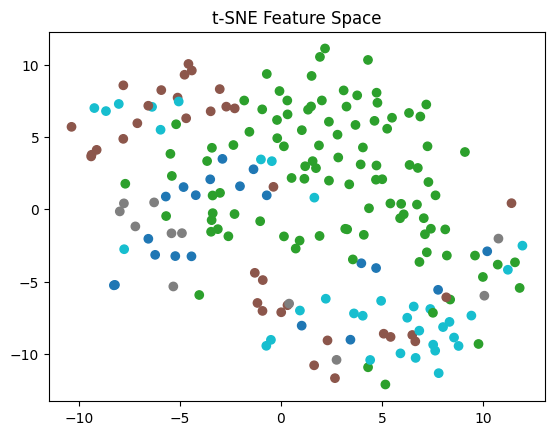

In [ ]:
resnet.eval()
feats, labs = [], []

with torch.no_grad():
    for x,y in val_loader:
        x = x.to(device)
        f = resnet.avgpool(resnet.layer4(
            resnet.layer3(resnet.layer2(resnet.layer1(
            resnet.relu(resnet.bn1(resnet.conv1(x))))))))
        f = f.view(f.size(0), -1)
        feats.append(f.cpu().numpy())
        labs.extend(y.numpy())

X = np.vstack(feats)
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labs, cmap="tab10")
plt.title("t-SNE Feature Space")
plt.show()


# PS6 — TRANSFER LEARNING

In [ ]:
!kaggle datasets download -d puneet6060/intel-image-classification
!unzip -oq intel-image-classification.zip

intel_ds = datasets.ImageFolder("seg_train/seg_train", transform=test_tf)
intel_loader = DataLoader(intel_ds, batch_size=32)


Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
intel-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
resnet.eval()
correct = total = 0
with torch.no_grad():
    for x,y in intel_loader:
        x,y = x.to(device), y.to(device)
        preds = torch.argmax(resnet(x),1)
        correct += (preds==y).sum().item()
        total += y.size(0)

print("Transfer Accuracy:", correct/total)


Transfer Accuracy: 0.16894684338036198


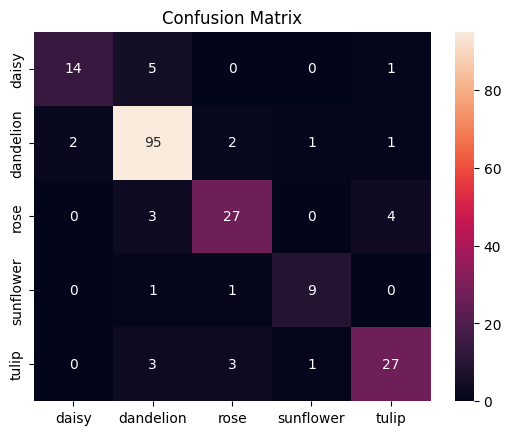

In [ ]:
cm = confusion_matrix(yt_r, yp_r)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix")
plt.show()


# DATASET 2 — INTEL IMAGE CLASSIFICATION

In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader
from collections import Counter


# Path after unzip
intel_root = "seg_train/seg_train"

intel_ds = datasets.ImageFolder(
    intel_root,
    transform=test_tf   # reuse same transform
)

intel_loader = DataLoader(
    intel_ds,
    batch_size=32,
    shuffle=True
)

intel_classes = intel_ds.classes
print("Intel Classes:", intel_classes)


Intel Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [ ]:
# Show class imbalance
intel_counts = Counter([y for _, y in intel_ds])
intel_counts


Counter({0: 2191, 1: 2271, 2: 2404, 3: 2512, 4: 2274, 5: 2382})

In [ ]:
from torchvision import models
import torch.nn as nn
import torch.optim as optim


In [ ]:
resnet_intel = models.resnet18(pretrained=True)
resnet_intel.fc = nn.Linear(
    resnet_intel.fc.in_features,
    len(intel_classes)
)
resnet_intel = resnet_intel.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
criterion_intel = nn.CrossEntropyLoss()
optimizer_intel = optim.AdamW(resnet_intel.parameters(), lr=1e-4)


In [ ]:
for epoch in range(3):
    resnet_intel.train()
    total_loss = 0

    for x, y in intel_loader:
        x, y = x.to(device), y.to(device)
        optimizer_intel.zero_grad()
        loss = criterion_intel(resnet_intel(x), y)
        loss.backward()
        optimizer_intel.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(intel_loader):.4f}")


Epoch 1, Loss: 0.3273
Epoch 2, Loss: 0.1320
Epoch 3, Loss: 0.0667


In [ ]:
from sklearn.metrics import classification_report, f1_score


In [ ]:
resnet_intel.eval()
y_true_i, y_pred_i = [], []

with torch.no_grad():
    for x, y in intel_loader:
        preds = torch.argmax(resnet_intel(x.to(device)), 1).cpu()
        y_true_i.extend(y)
        y_pred_i.extend(preds)

print(classification_report(y_true_i, y_pred_i, target_names=intel_classes))
print("Intel Macro-F1:", f1_score(y_true_i, y_pred_i, average="macro"))


              precision    recall  f1-score   support

   buildings       1.00      1.00      1.00      2191
      forest       1.00      1.00      1.00      2271
     glacier       1.00      0.96      0.98      2404
    mountain       0.96      1.00      0.98      2512
         sea       1.00      1.00      1.00      2274
      street       1.00      1.00      1.00      2382

    accuracy                           0.99     14034
   macro avg       0.99      0.99      0.99     14034
weighted avg       0.99      0.99      0.99     14034

Intel Macro-F1: 0.9911224317164319
